:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`manual_batching_loop.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings

# Ignore the specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Manual update loop for more control

While `GLM.stochastic_fit` provides a convenient interface for most use cases, in some situations fine-grained manual control during the optimization loop might be required.

As a starting point for more advanced users needing such control, we show how to manually set up a training loop performing stochastic gradient descent (SGD).

:::{warning}
SVRG is particularly suited for stochastic optimization, but its optimization loop is more involved than for SGD, so using `GLM.stochastic_fit` is highly recommended.
:::

## Set up the data and model

In [2]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap
import seaborn as sns

import nemos as nmo
from nemos._documentation_utils._stochastic_optim_toy_data import (
    _simulate_batching_data,
)

jax.config.update("jax_enable_x64", True)
nap.nap_config.suppress_conversion_warnings = True
np.random.seed(123)

This approach doesn't require the use of a NeMoS data loader, you can load batches of data any way you want. Here, we will use in-memory data and `ArrayDataLoader` for simplicity.

In [3]:
units, spike_trains, X = _simulate_batching_data()

loader = nmo.batching.ArrayDataLoader(X, spike_trains, batch_size=100)

Use gradient descent as the solver with a constant stepsize and acceleration disabled:

In [4]:
glm = nmo.glm.PopulationGLM(
    solver_name="GradientDescent",
    regularizer="Ridge",
    regularizer_strength=0.01,
    solver_kwargs={"stepsize": 0.05, "acceleration": False},
)

## Manual update loop calling `GLM.update`

Basic SGD can effectively be reproduced by the following manual loop with score logging included after every batch:

In [5]:
n_passes = 10

In [6]:
X_sample, y_sample = loader.sample_batch()
params = glm.initialize_params(X_sample, y_sample)
opt_state = glm.initialize_optimizer_and_state(params, X_sample, y_sample)

scores = []
for i in range(n_passes):
    for X_batch, y_batch in loader:
        params, opt_state = glm.update(params, opt_state, X_batch, y_batch)
        scores.append(glm.score(X, spike_trains))

Plotting the resulting scores shows a similar curve as in previous sections using `GLM.stochastic_fit`:

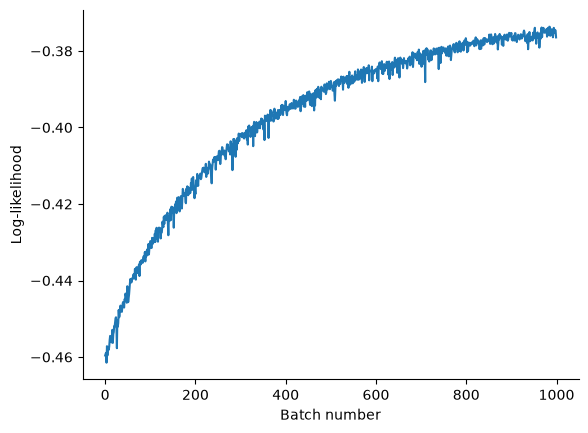

In [7]:
fig, ax = plt.subplots()

ax.plot(scores)
ax.set_xlabel("Batch number")
ax.set_ylabel("Log-likelihood")

sns.despine(ax=ax)